In [1]:
import RF_Track as rft
import numpy as np
import matplotlib.pyplot as plt
import pymadx


RF-Track, version 2.5.4

Copyright (C) 2016-2025 CERN, Geneva, Switzerland. All rights reserved.

Author and contact:
 Andrea Latina <andrea.latina@cern.ch>
 BE-ABP Group
 CERN
 CH-1211 GENEVA 23
 SWITZERLAND

This software is distributed under a CERN proprietary software
license in the hope that it will be useful, but WITHOUT ANY WARRANTY;
not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

See the COPYRIGHT and LICENSE files at the top-level directory of
the RF-Track download area: https://gitlab.cern.ch/rf-track

RF-Track was compiled with GSL-2.5 and fftw-3.3.5-sse2-avx



[RF-Track] Could not check for updates.


In [2]:
# Bunch parameters
mass = rft.protonmass # MeV/c^2
charge = 1 # single-particle charge, in units of e
population = int(1e14) # number of real particles per bunch. The real number for NICA 1e12.
nParticles = int(1e3) # number of macroparticles
En = 7e3 # Total energy [MeV]
Pref = np.sqrt(En**2 - mass**2) # reference momentum, MeV/c
P_Q = Pref / charge # MV/c, reference rigidity

Define Lattice from MADX Twiss Table

In [3]:
ARC = rft.Lattice('/media/sf_GIT_REPOS/NICA/MADX/tbl/twiss_temp_arc.tbl')
ARC_IBS = rft.Lattice('/media/sf_GIT_REPOS/NICA/MADX/tbl/twiss_temp_arc.tbl')

In [4]:
print(ARC.size())
print(ARC.get_length())

1417
503.0400000132004


In [5]:
# Algorithm parameters
dt = 10 # Integration step, mm/c
NT = 16 # Transversal mesh points
NZ = 16 # Longitudinal mesh points
Ncol = 200 # Maximum number of iter.
IBS = rft.IntraBeamScattering(NT, NT, NZ, Ncol)

Add Collective effect (IBS) for each element in lattice

In [6]:
for _ in range(int(ARC_IBS.size())):
    ARC_IBS[_].add_collective_effect(IBS)
    ARC_IBS[_].set_cfx_nsteps(1)

In [7]:
ARC_IBS['RFCAVITY']

[]

In [8]:
Twiss = rft.Bunch6d_twiss()
Twiss.emitt_x = 1*7.460522474 # mm.mrad, normalized emittances
Twiss.emitt_y = 1*7.460522474 # mm.mrad
Twiss.alpha_x = -0.02538838593
Twiss.alpha_y = -0.02612631742
Twiss.beta_x = 61.32481812e-2 # m
Twiss.beta_y = 73.80216969e-2 # m
Twiss.sigma_t = 0 # mm/c
Twiss.sigma_pt = 0.0015 # permille, 1%

B0 = rft.Bunch6d(mass, population, charge, Pref, Twiss, nParticles)

In [9]:
%%time
B1 = ARC.track(B0)

CPU times: user 4.03 s, sys: 8.3 s, total: 12.3 s
Wall time: 6.96 s


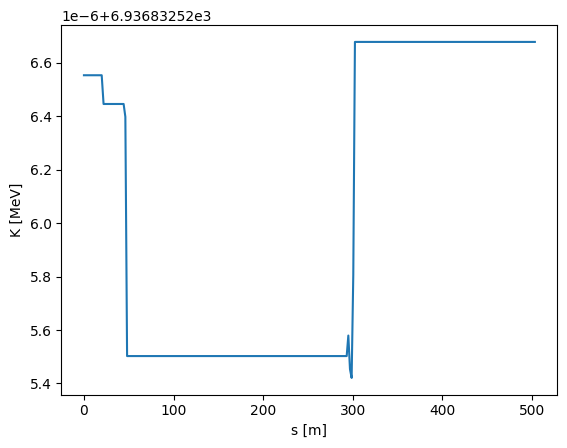

In [10]:
#Acceleration plot
T = ARC.get_transport_table('%S %mean_P')

plt.plot (T[:, 0], T[:, 1])
plt.xlabel ('s [m]')
plt.ylabel ('K [MeV]')
plt.show()

In [11]:
%%time
B1_IBS = ARC_IBS.track(B0)

CPU times: user 1min 20s, sys: 51.6 s, total: 2min 12s
Wall time: 37.5 s


In [12]:
T = ARC.get_transport_table('%S %beta_x %beta_y %emitt_x %emitt_y %sigma_x %sigma_y');
T_IBS = ARC_IBS.get_transport_table('%S %beta_x %beta_y %emitt_x %emitt_y %sigma_x %sigma_y');

pymadx.Tfs.Load> normal file


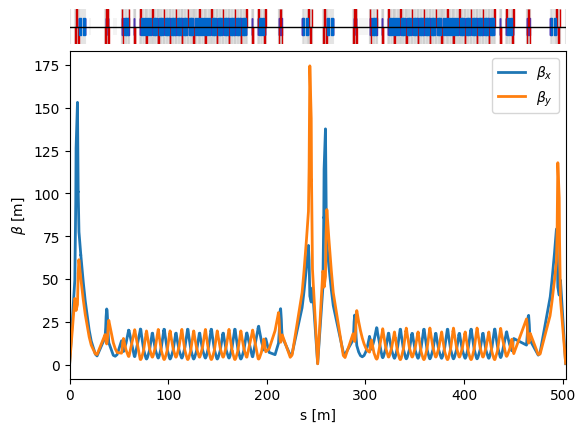

In [13]:
fig = plt.figure()
plt.plot(T[:,0], T[:,1], linewidth=2, label=r'$\beta_x$')
plt.plot(T[:,0], T[:,2], linewidth=2, label=r'$\beta_y$')
plt.legend()
plt.xlabel('s [m]')
plt.ylabel(r'$\beta$ [m]')
pymadx.Plot.AddMachineLatticeToFigure(fig, '/media/sf_GIT_REPOS/NICA/MADX/tbl/twiss_temp_arc.tbl')
plt.show()

pymadx.Tfs.Load> normal file


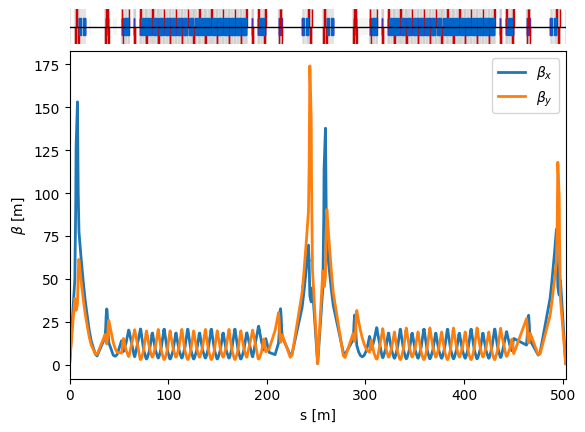

In [14]:
fig = plt.figure()
plt.plot(T_IBS[:,0], T_IBS[:,1], linewidth=2, label=r'$\beta_x$')
plt.plot(T_IBS[:,0], T_IBS[:,2], linewidth=2, label=r'$\beta_y$')
plt.legend()
plt.xlabel('s [m]')
plt.ylabel(r'$\beta$ [m]')
pymadx.Plot.AddMachineLatticeToFigure(fig, '/media/sf_GIT_REPOS/NICA/MADX/tbl/twiss_temp_arc.tbl')
plt.show()

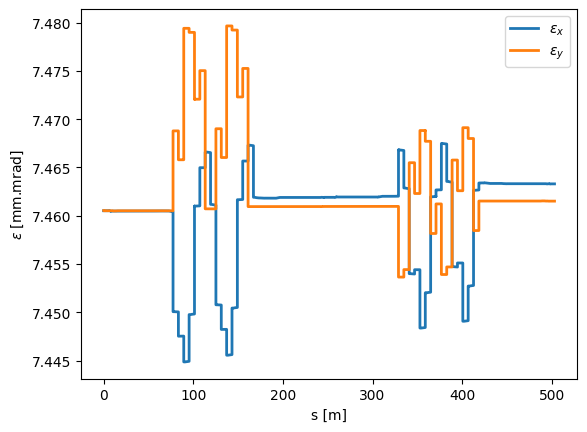

In [15]:
plt.plot(T[:,0], T[:,3], linewidth=2, label=r'$\epsilon_x$')
plt.plot(T[:,0], T[:,4], linewidth=2, label=r'$\epsilon_y$')
plt.xlabel('s [m]')
plt.ylabel(r'$\epsilon$ [mm.mrad]')
plt.legend()
plt.show()

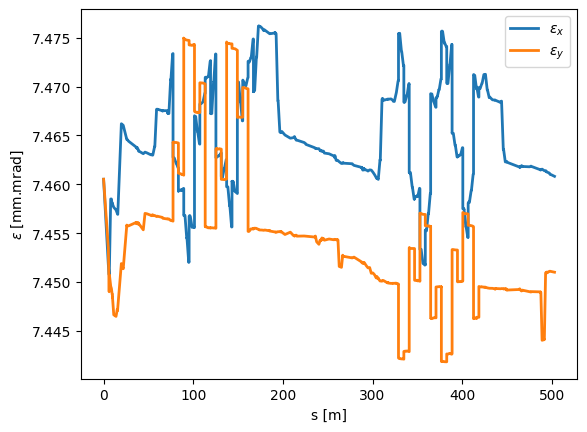

In [16]:
plt.plot(T_IBS[:,0], T_IBS[:,3], linewidth=2, label=r'$\epsilon_x$')
plt.plot(T_IBS[:,0], T_IBS[:,4], linewidth=2, label=r'$\epsilon_y$')
plt.xlabel('s [m]')
plt.ylabel(r'$\epsilon$ [mm.mrad]')
plt.legend()
plt.show()

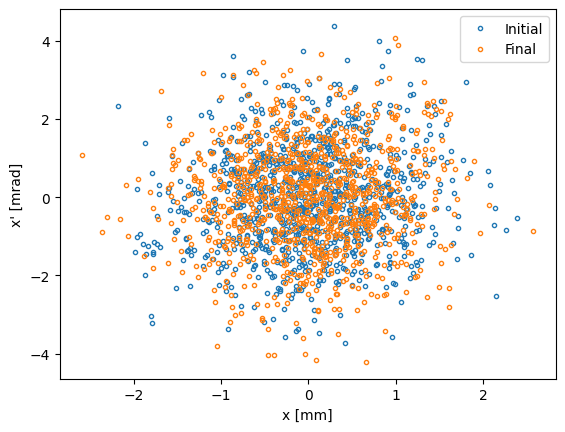

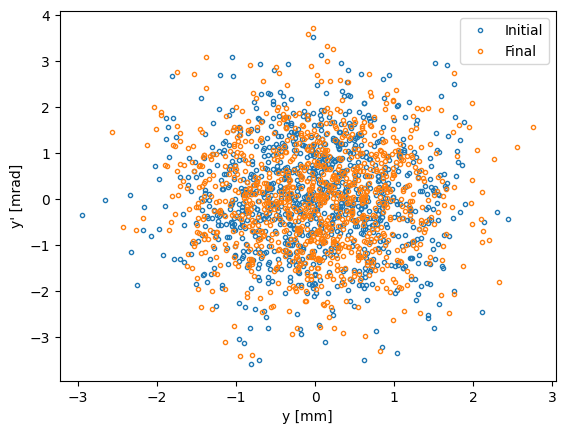

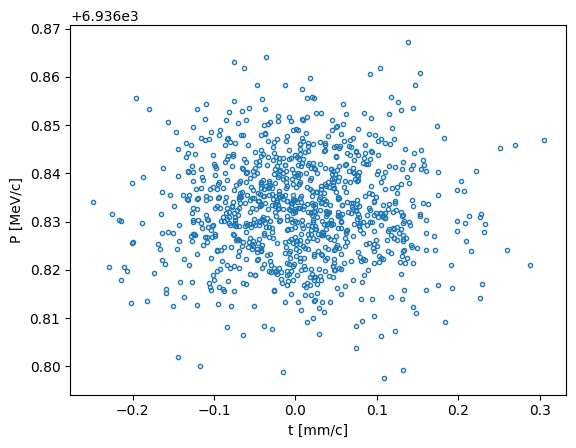

In [17]:
M0 = B0.get_phase_space ('%x %xp %y %yp %dt %P')
M1 = B1.get_phase_space ('%x %xp %y %yp %dt %P')

plt.figure()
plt.plot(M0[:,0], M0[:,1], '.', label='Initial', mfc='none')
plt.plot(M1[:,0], M1[:,1], '.', label='Final', mfc='none')
plt.xlabel('x [mm]')
plt.ylabel("x' [mrad]")
plt.legend()

plt.figure()
plt.plot(M0[:,2], M0[:,3], '.', label='Initial', mfc='none')
plt.plot(M1[:,2], M1[:,3], '.', label='Final', mfc='none')
plt.xlabel('y [mm]')
plt.ylabel("y' [mrad]")
plt.legend()

plt.figure()
plt.plot(M1[:,4], M1[:,5], '.', label='Final', mfc='none')
plt.xlabel('t [mm/c]')
plt.ylabel('P [MeV/c]')
plt.show()

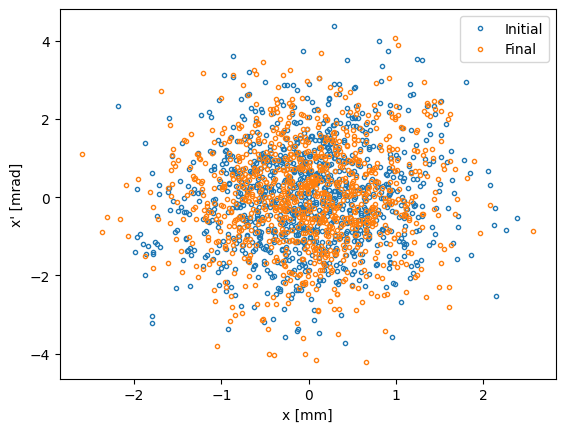

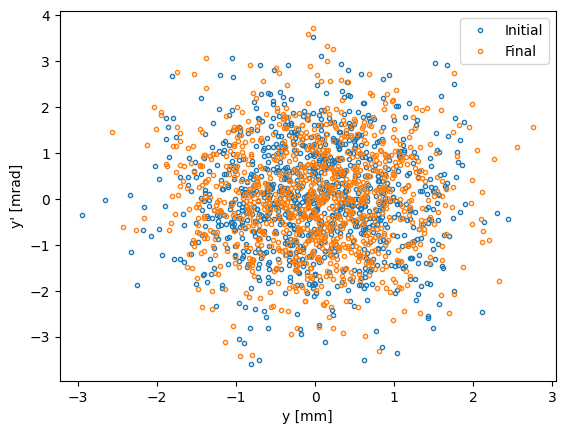

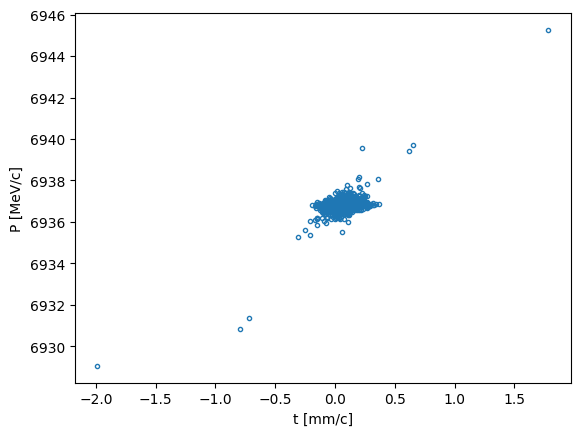

In [18]:
M0 = B0.get_phase_space ('%x %xp %y %yp %dt %P')
M1 = B1_IBS.get_phase_space ('%x %xp %y %yp %dt %P')

plt.figure()
plt.plot(M0[:,0], M0[:,1], '.', label='Initial', mfc='none')
plt.plot(M1[:,0], M1[:,1], '.', label='Final', mfc='none')
plt.xlabel('x [mm]')
plt.ylabel("x' [mrad]")
plt.legend()

plt.figure()
plt.plot(M0[:,2], M0[:,3], '.', label='Initial', mfc='none')
plt.plot(M1[:,2], M1[:,3], '.', label='Final', mfc='none')
plt.xlabel('y [mm]')
plt.ylabel("y' [mrad]")
plt.legend()

plt.figure()
plt.plot(M1[:,4], M1[:,5], '.', label='Final', mfc='none')
plt.xlabel('t [mm/c]')
plt.ylabel('P [MeV/c]')
plt.show()

In [19]:
# function for tracking in lattice over several turns
def multiturn_track(closed_lattice, initial_bunch, N_turns):
    
    current_bunch = initial_bunch
    
    data_collector = [] # for bunch parameters over turn
    
    for turn_num in range(N_turns):
        final_bunch = closed_lattice.track(current_bunch)
        current_bunch = final_bunch
        #print(f'Turn: {_} complete') 

        I = final_bunch.get_info()

        #save bunch parmeters after each turn
        current_row = [
            turn_num + 1,  # turn number
            #I.mean_K,
            #I.emitt_x,
            #I.emitt_y,
            #I.emitt_4d
            #I.emitt_6d
            I.S,
            I.mean_x,
            I.mean_y,
            I.mean_t,
            I.mean_xp,
            I.mean_yp,
            I.mean_Px,
            I.mean_Py,
            I.mean_Pz,
            I.mean_P,
            I.mean_K,
            I.mean_E, #12
            I.sigma_x,
            I.sigma_y,
            I.sigma_t,
            I.sigma_E,
            I.sigma_P,
            I.emitt_x, #18
            I.emitt_y, #19
            I.emitt_z, 
            I.emitt_4d, #21
            I.emitt_6d, #22
            I.alpha_x,
            I.alpha_y,
            I.alpha_z,
            I.beta_x,
            I.beta_y,
            I.beta_z,
            I.rmax, #29
            I.transmission
        ]

        #collect data 
        data_collector.append(current_row)
        # print(f'Turn: {turn_num + 1} complete. Emitt_x: {I.emitt_x:.2e}')

    #convert
    beam_parameters_array = np.array(data_collector)
    return final_bunch, beam_parameters_array

In [20]:
%%time
B_final, bunch_data = multiturn_track(ARC, B0, 20)

CPU times: user 36 s, sys: 1min 22s, total: 1min 58s
Wall time: 58.4 s


In [21]:
%%time
B_final_IBS, bunch_data_IBS = multiturn_track(ARC_IBS, B0, 20)

CPU times: user 14min 12s, sys: 8min 41s, total: 22min 53s
Wall time: 5min 56s


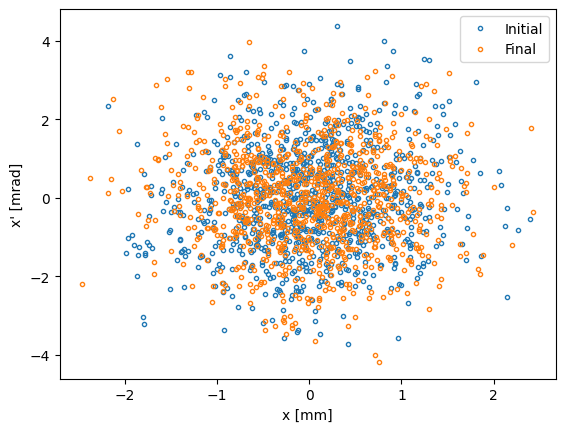

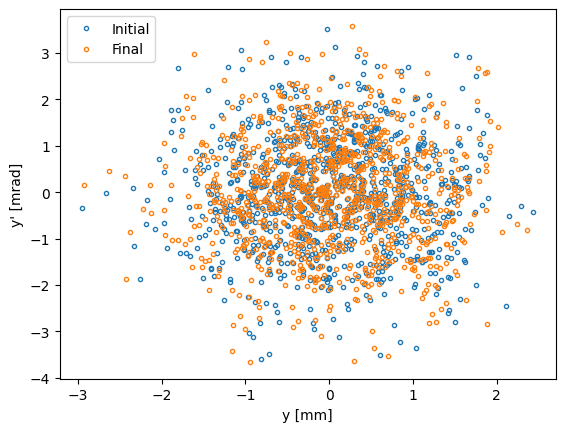

In [22]:
M0 = B0.get_phase_space ('%x %xp %y %yp %dt %P')
M1 = B_final.get_phase_space ('%x %xp %y %yp %dt %P')

plt.figure()
plt.plot(M0[:,0], M0[:,1], '.', label='Initial', mfc='none')
plt.plot(M1[:,0], M1[:,1], '.', label='Final', mfc='none')
plt.xlabel('x [mm]')
plt.ylabel("x' [mrad]")
plt.legend()

plt.figure()
plt.plot(M0[:,2], M0[:,3], '.', label='Initial', mfc='none')
plt.plot(M1[:,2], M1[:,3], '.', label='Final', mfc='none')
plt.xlabel('y [mm]')
plt.ylabel("y' [mrad]")
plt.legend()
plt.show()

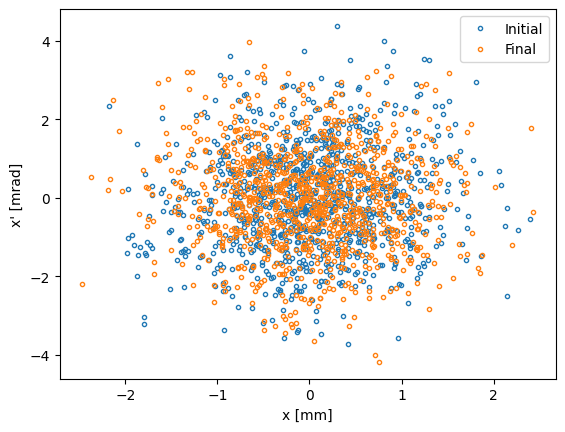

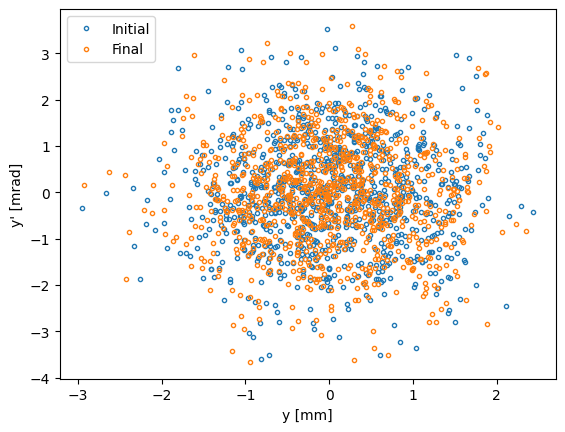

In [23]:
M0 = B0.get_phase_space ('%x %xp %y %yp %dt %P')
M1 = B_final_IBS.get_phase_space ('%x %xp %y %yp %dt %P')

plt.figure()
plt.plot(M0[:,0], M0[:,1], '.', label='Initial', mfc='none')
plt.plot(M1[:,0], M1[:,1], '.', label='Final', mfc='none')
plt.xlabel('x [mm]')
plt.ylabel("x' [mrad]")
plt.legend()

plt.figure()
plt.plot(M0[:,2], M0[:,3], '.', label='Initial', mfc='none')
plt.plot(M1[:,2], M1[:,3], '.', label='Final', mfc='none')
plt.xlabel('y [mm]')
plt.ylabel("y' [mrad]")
plt.legend()
plt.show()

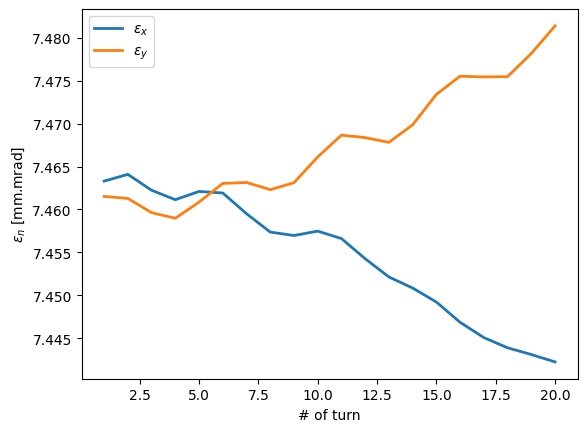

In [24]:
plt.plot(bunch_data[:,0], bunch_data[:,18], linewidth=2, label=r'$\epsilon_x$')
plt.plot(bunch_data[:,0], bunch_data[:,19], linewidth=2, label=r'$\epsilon_y$')
plt.legend()
plt.xlabel('# of turn')
plt.ylabel(r'$\epsilon_n$ [mm.mrad]')
plt.show()

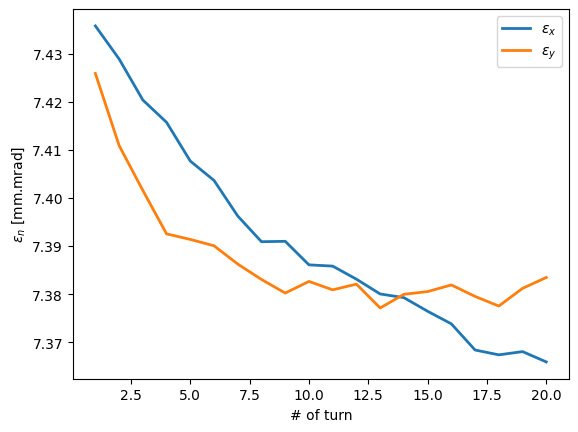

In [25]:
plt.plot(bunch_data_IBS[:,0], bunch_data_IBS[:,18], linewidth=2, label=r'$\epsilon_x$')
plt.plot(bunch_data_IBS[:,0], bunch_data_IBS[:,19], linewidth=2, label=r'$\epsilon_y$')
plt.legend()
plt.xlabel('# of turn')
plt.ylabel(r'$\epsilon_n$ [mm.mrad]')
plt.show()

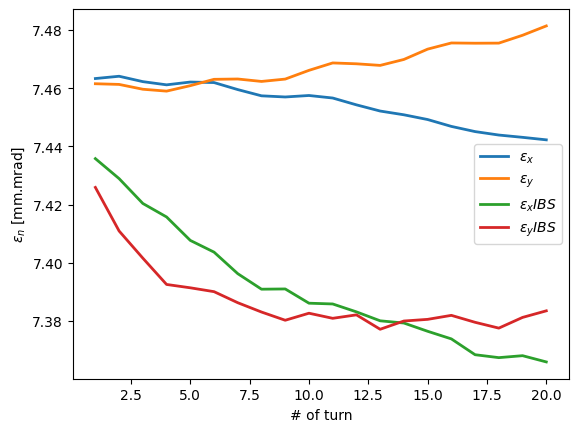

In [26]:
plt.plot(bunch_data[:,0], bunch_data[:,18], linewidth=2, label=r'$\epsilon_x$')
plt.plot(bunch_data[:,0], bunch_data[:,19], linewidth=2, label=r'$\epsilon_y$')
plt.plot(bunch_data_IBS[:,0], bunch_data_IBS[:,18], linewidth=2, label=r'$\epsilon_xIBS$')
plt.plot(bunch_data_IBS[:,0], bunch_data_IBS[:,19], linewidth=2, label=r'$\epsilon_yIBS$')
plt.legend()
plt.xlabel('# of turn')
plt.ylabel(r'$\epsilon_n$ [mm.mrad]')
plt.show()

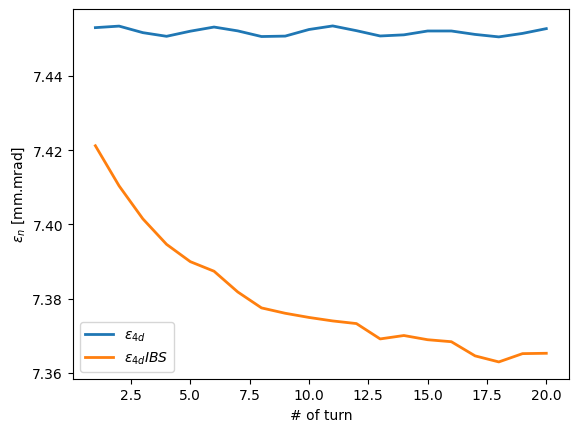

In [27]:
plt.plot(bunch_data[:,0], bunch_data[:,21], linewidth=2, label=r'$\epsilon_{4d}$')
plt.plot(bunch_data_IBS[:,0], bunch_data_IBS[:,21], linewidth=2, label=r'$\epsilon_{4d}IBS$')
plt.legend()
plt.xlabel('# of turn')
plt.ylabel(r'$\epsilon_n$ [mm.mrad]')
plt.show()

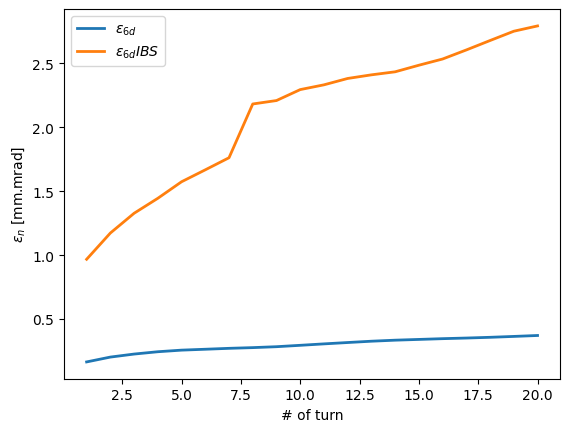

In [28]:
plt.plot(bunch_data[:,0], bunch_data[:,22], linewidth=2, label=r'$\epsilon_{6d}$')
plt.plot(bunch_data_IBS[:,0], bunch_data_IBS[:,22], linewidth=2, label=r'$\epsilon_{6d}IBS$')
plt.legend()
plt.xlabel('# of turn')
plt.ylabel(r'$\epsilon_n$ [mm.mrad]')
plt.show()